In [29]:
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt

In [2]:
df = pd.read_parquet("data/processed/ord_departures_bts_2020_present.parquet")

In [4]:
df.shape

(1607779, 52)

In [5]:
df.columns

Index(['year', 'quarter', 'month', 'day_of_month', 'day_of_week',
       'flight_date', 'reporting_airline', 'dot_id_reporting_airline',
       'iata_code_reporting_airline', 'tail_number',
       'flight_number_reporting_airline', 'origin', 'origin_city_name',
       'origin_state', 'dest', 'dest_city_name', 'dest_state', 'crs_dep_time',
       'crs_arr_time', 'crs_elapsed_time', 'distance',
       'scheduled_dep_datetime', 'scheduled_arr_datetime', 'dep_time',
       'dep_delay', 'dep_delay_minutes', 'dep_del15', 'departure_delay_groups',
       'taxi_out', 'wheels_off', 'wheels_on', 'taxi_in', 'arr_time',
       'arr_delay', 'arr_delay_minutes', 'arr_del15', 'arrival_delay_groups',
       'cancelled', 'cancellation_code', 'diverted', 'actual_elapsed_time',
       'air_time', 'carrier_delay', 'weather_delay', 'nas_delay',
       'security_delay', 'late_aircraft_delay', 'disrupted', 'delayed',
       'canceled', 'diverted_flag', 'weather_related'],
      dtype='str')

In [10]:
num_nans = df.isna().sum()

print('Columns with nans:')
num_nans[num_nans != 0]

Columns with nans:


tail_number                 10818
scheduled_arr_datetime          4
dep_time                    36110
dep_delay                   36278
dep_delay_minutes           36278
dep_del15                   36278
departure_delay_groups      36278
taxi_out                    37098
wheels_off                  37098
wheels_on                   37923
taxi_in                     37923
arr_time                    37923
arr_delay                   41408
arr_delay_minutes           41408
arr_del15                   41408
arrival_delay_groups        41408
cancellation_code         1570424
actual_elapsed_time         41408
air_time                    41408
dtype: int64

<Axes: >

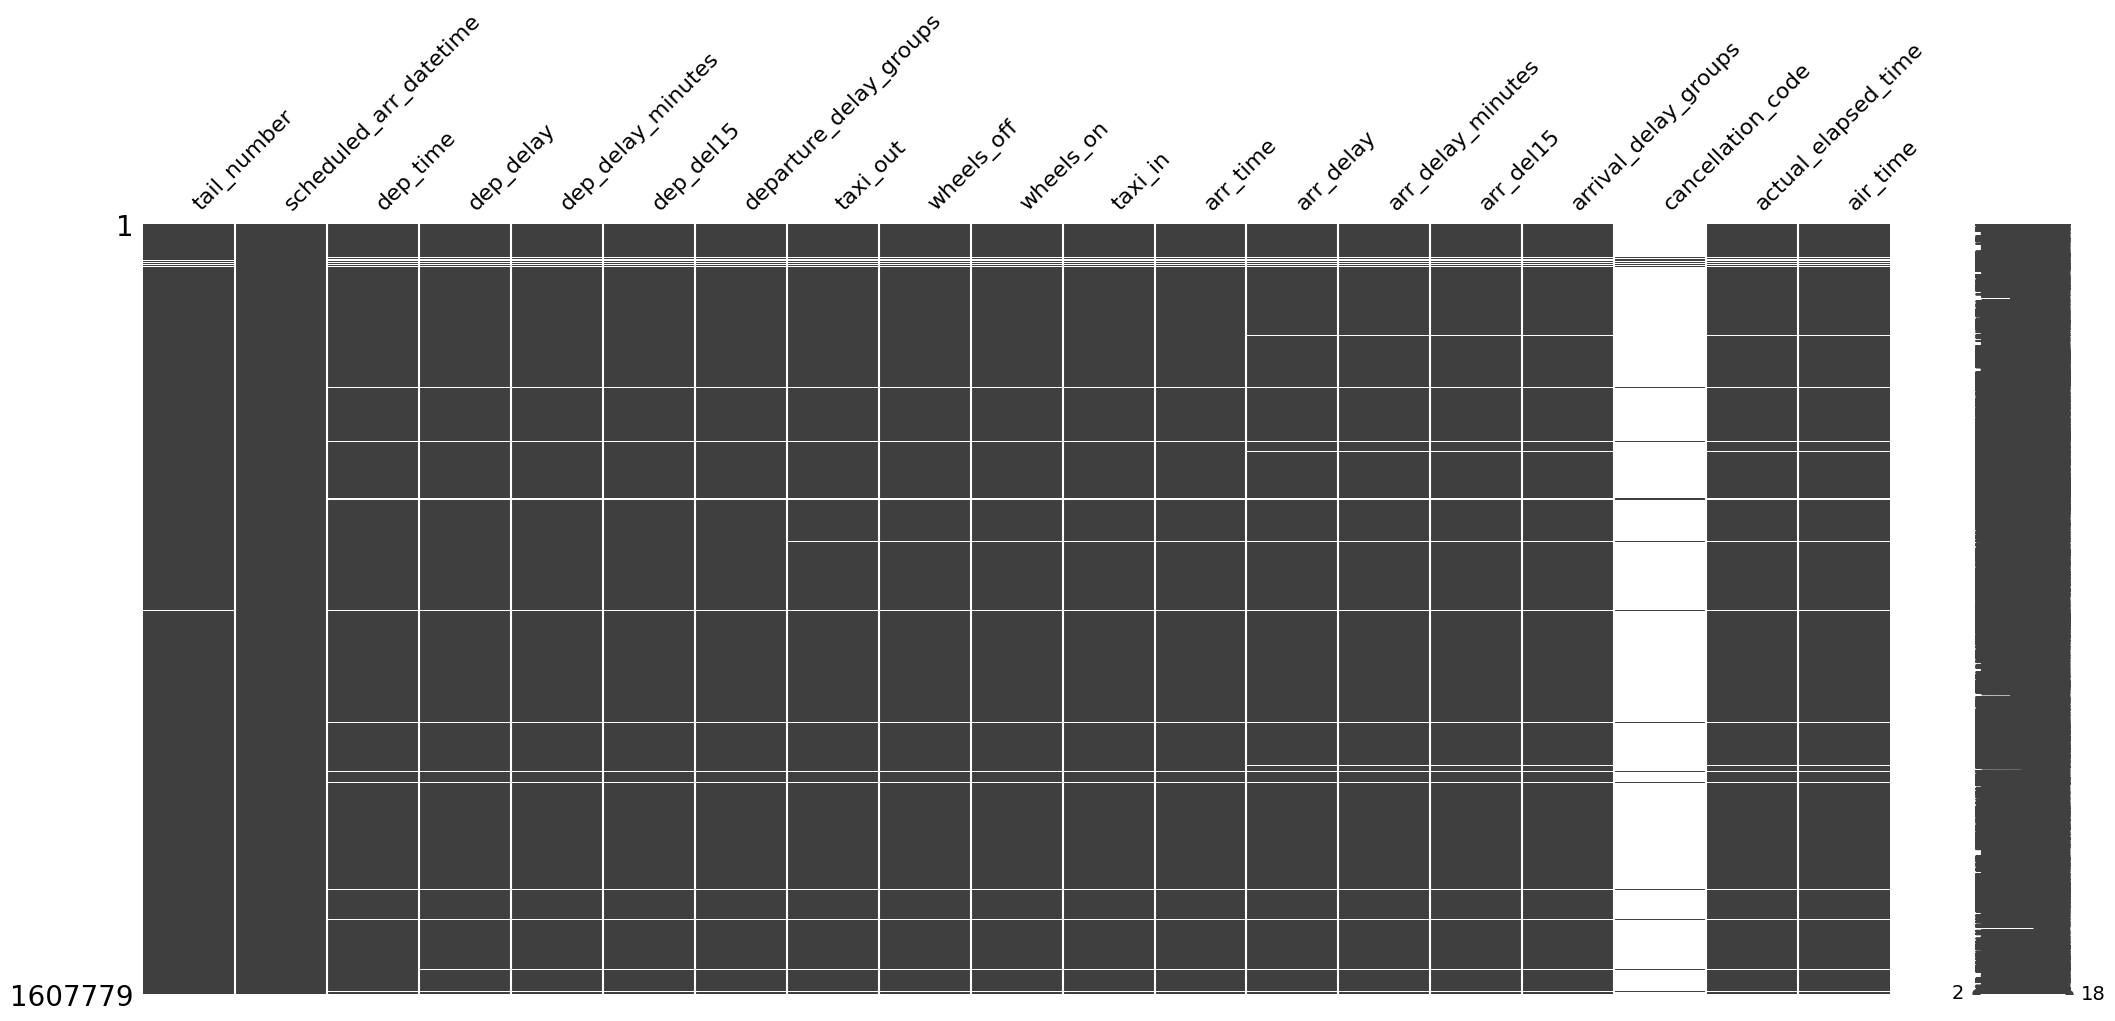

In [22]:
cols_w_missing = df.columns[df.isna().any()].tolist()
msno.matrix(df.loc[:,cols_w_missing])

In [27]:
covid_cancellations = df.loc[(df['cancellation_code'].notna()) &
       (df['year'] == 2020), 'flight_date'].value_counts()

covid_cancellations

flight_date
2020-03-30    517
2020-03-26    505
2020-03-27    452
2020-03-31    447
2020-03-29    430
             ... 
2020-12-18      1
2020-12-19      1
2020-12-20      1
2020-12-21      1
2020-12-24      1
Name: count, Length: 226, dtype: int64

Lots of cancellations due to COVID-19, 

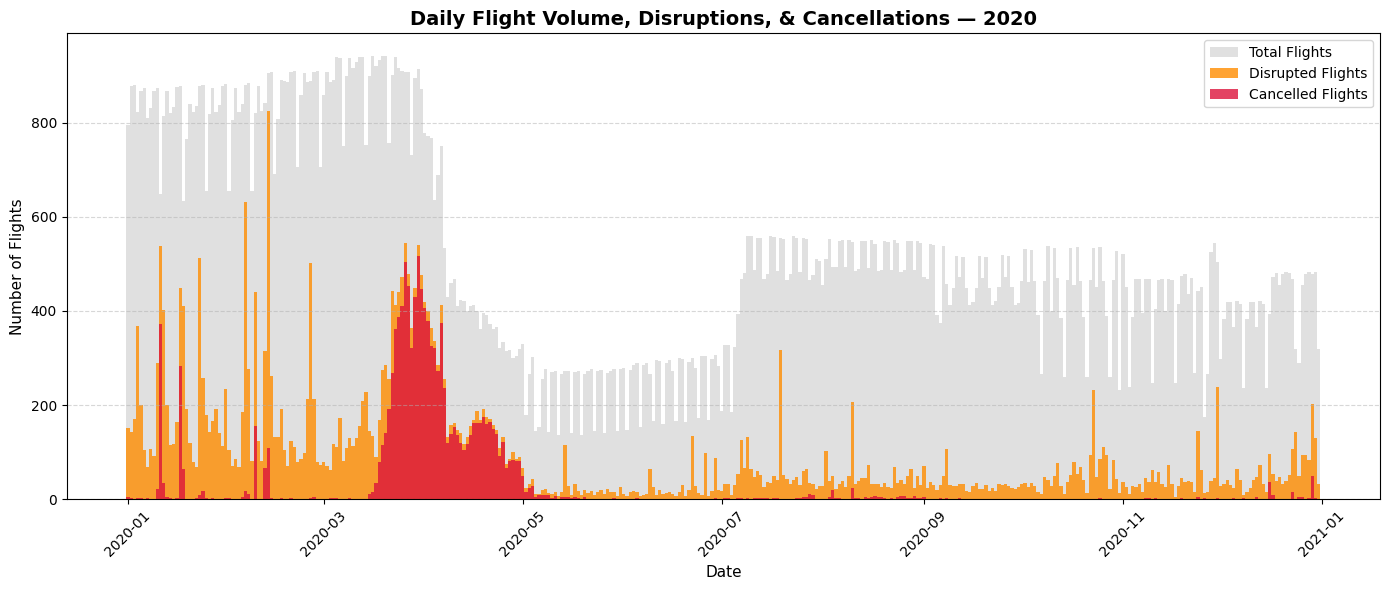

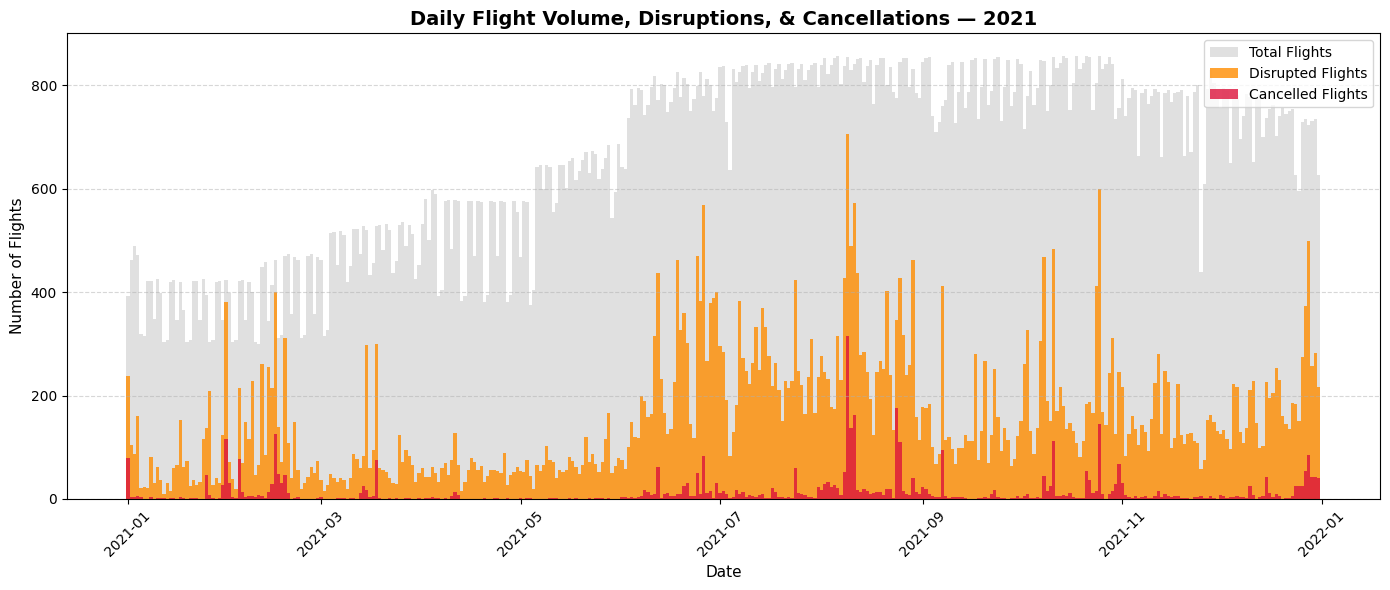

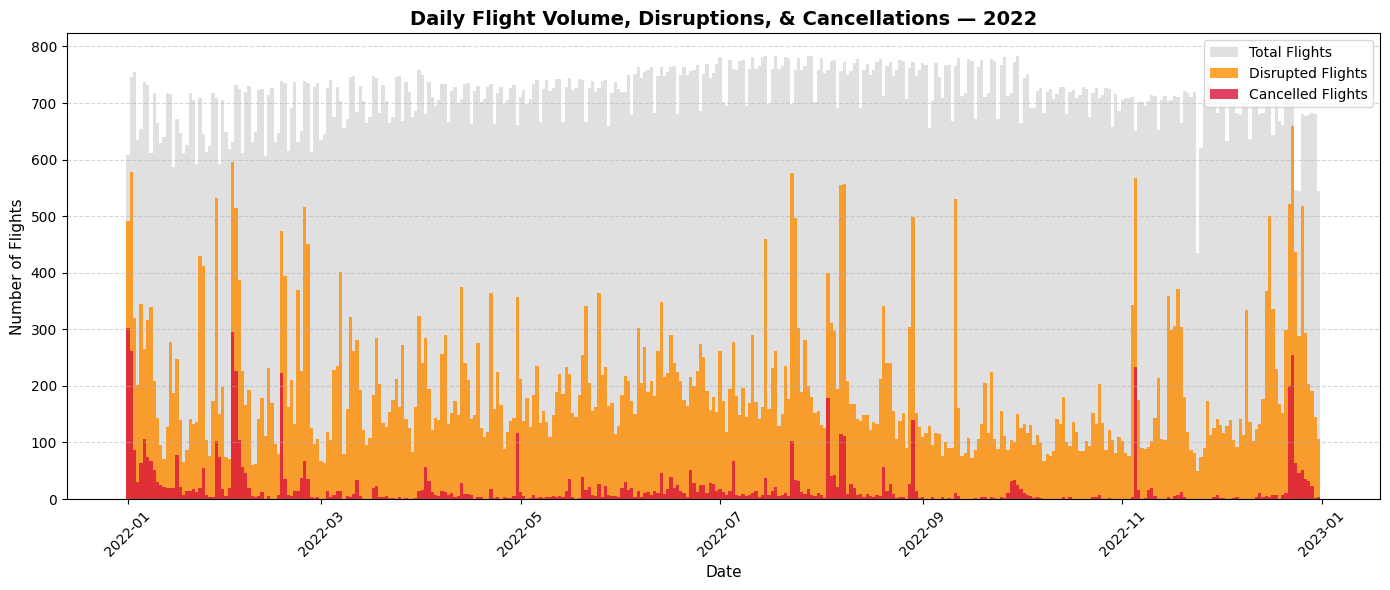

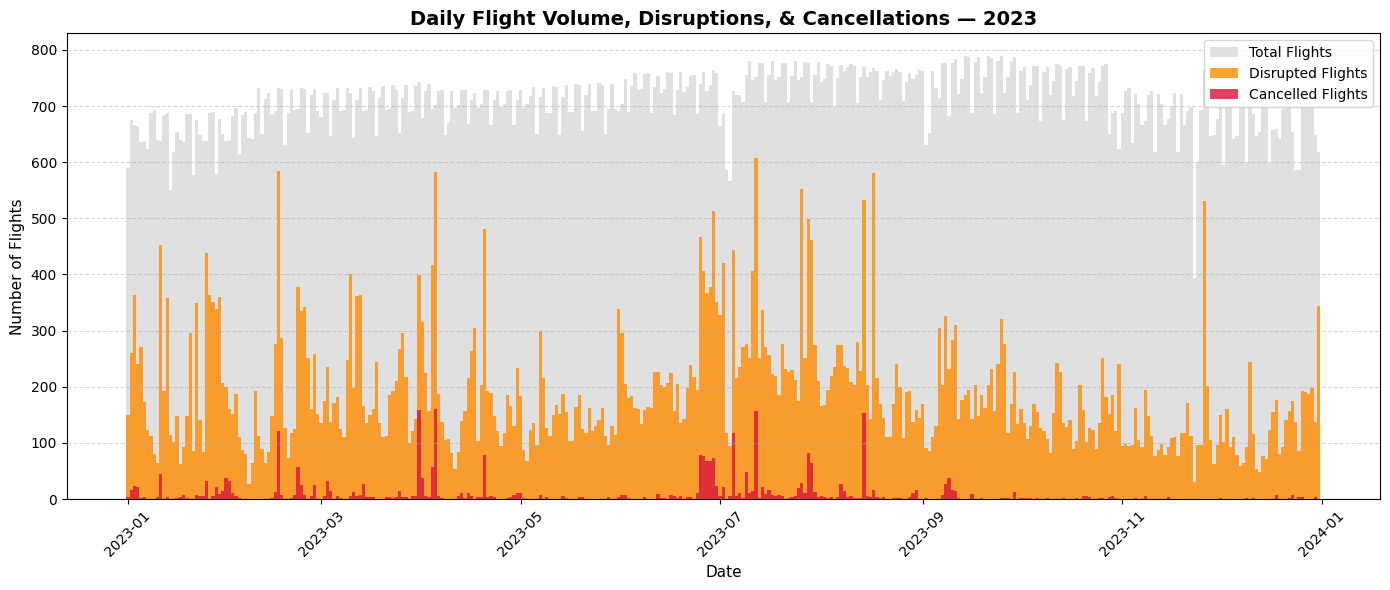

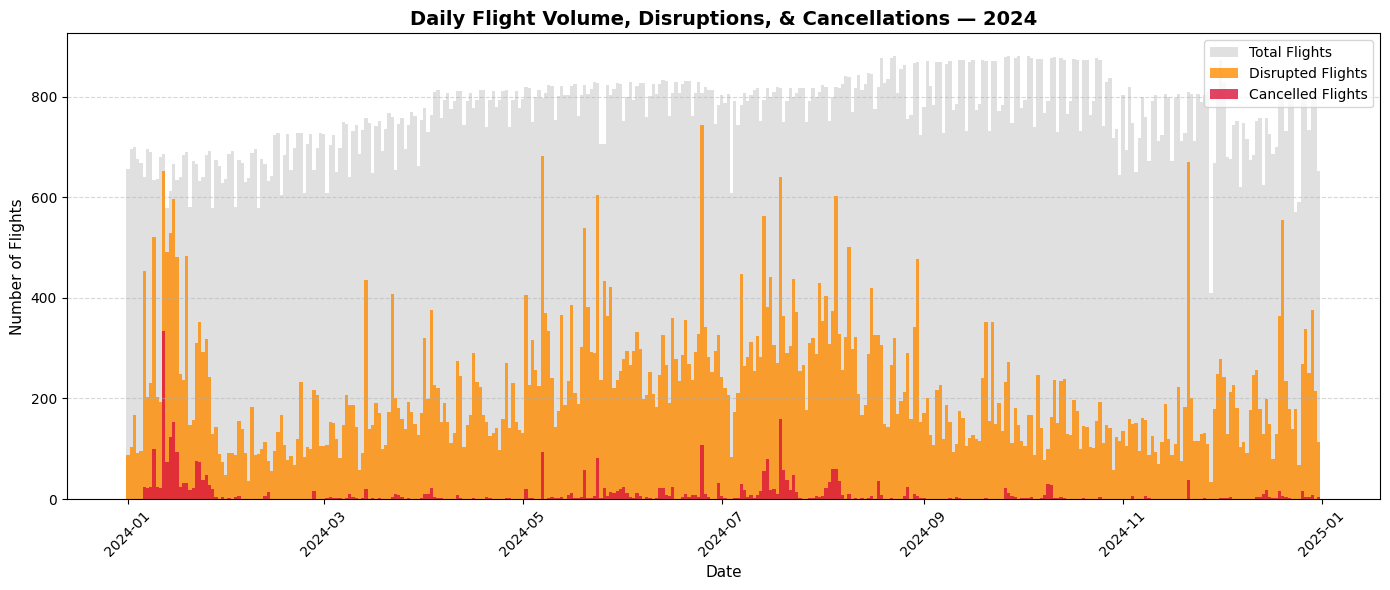

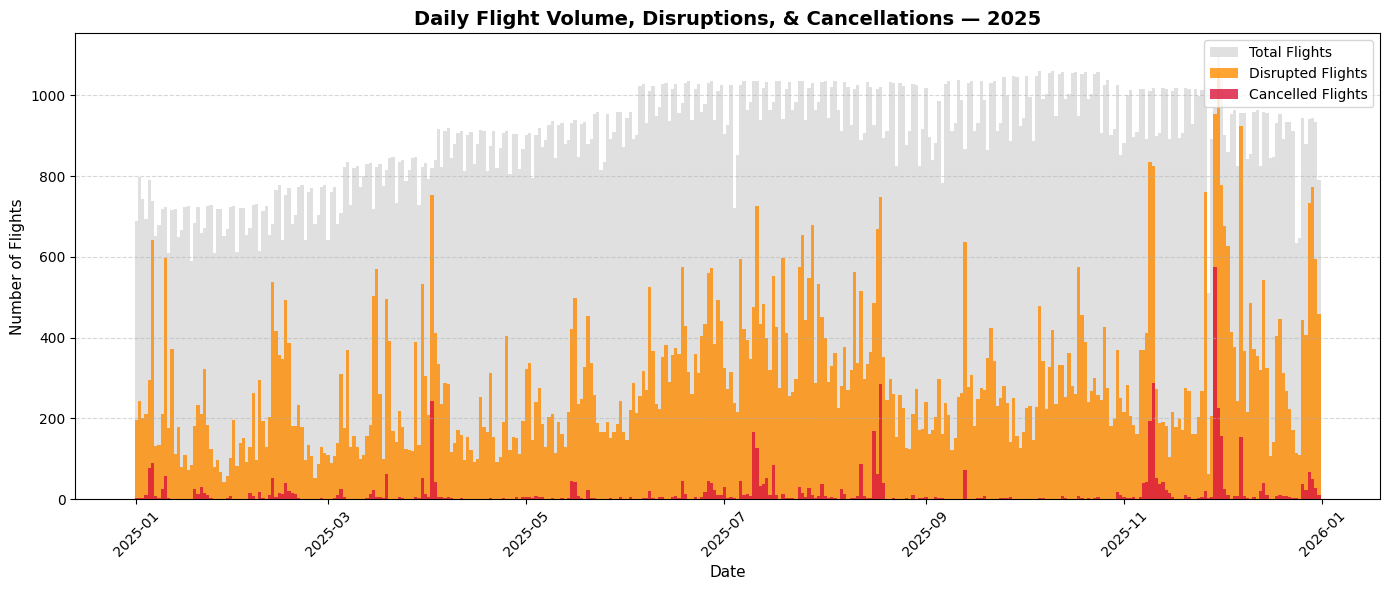

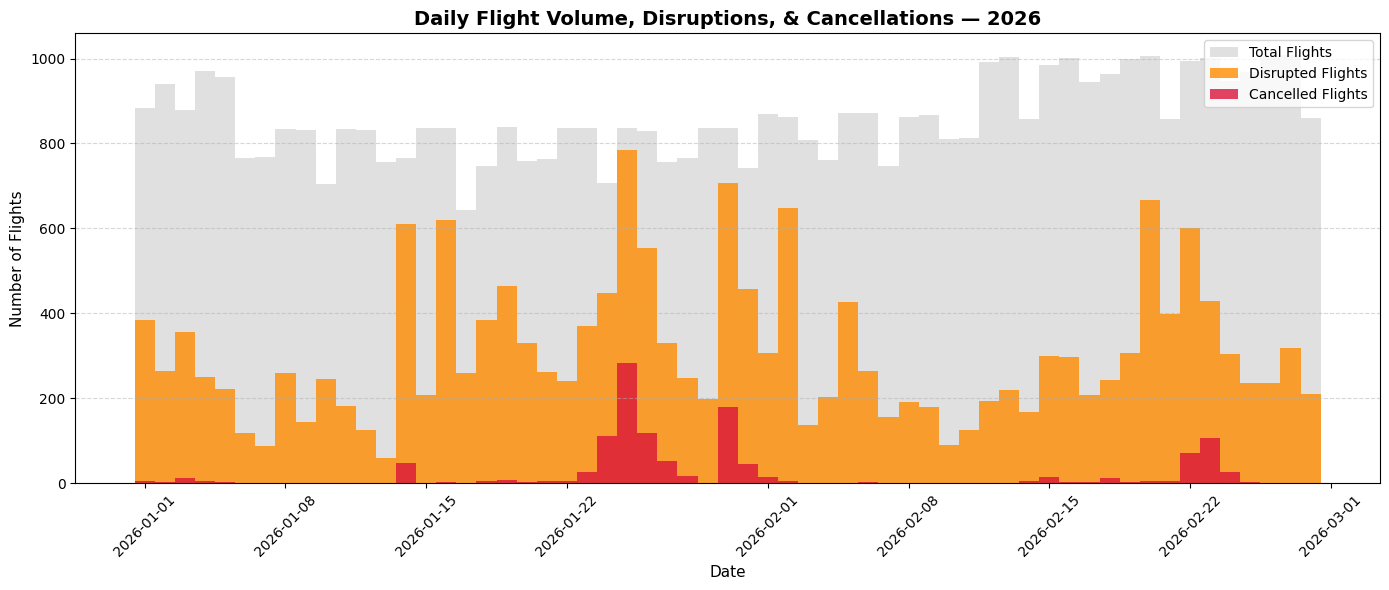

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# 2. Loop through the years 2020 to 2025
for year in range(2020, 2027):
    
    # Filter data for the specific year
    df_year = df[df['year'] == year]
    
    if df_year.empty:
        print(f"No data found for the year {year}. Skipping...")
        continue
        
    # Group by flight_date to get daily totals, cancellations, and disruptions all at once
    daily_stats = df_year.groupby('flight_date').agg(
        total_flights=('cancelled', 'count'),      # Counting rows gives total flights
        cancelled_flights=('cancelled', 'sum'),    # Summing 0/1 gives total cancellations
        disrupted_flights=('disrupted', 'sum')     # Summing 0/1 gives total disruptions
    ).sort_index()
    
    # 3. Create the plot for the current year
    plt.figure(figsize=(14, 6))
    
    # Plot Total Flights as the background baseline
    plt.bar(daily_stats.index, daily_stats['total_flights'], 
            width=1.0, color='lightgray', alpha=0.7, label='Total Flights')
    
    # Plot Disrupted Flights 
    plt.bar(daily_stats.index, daily_stats['disrupted_flights'], 
            width=1.0, color='darkorange', alpha=0.8, label='Disrupted Flights')
    
    # Plot Cancelled Flights 
    # (Plotted last so it sits on top of disruptions if they happen on the same day)
    plt.bar(daily_stats.index, daily_stats['cancelled_flights'], 
            width=1.0, color='crimson', alpha=0.8, label='Cancelled Flights')
    
    # 4. Chart Formatting
    plt.title(f'Daily Flight Volume, Disruptions, & Cancellations — {year}', fontsize=14, fontweight='bold')
    plt.xlabel('Date', fontsize=11)
    plt.ylabel('Number of Flights', fontsize=11)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.xticks(rotation=45)
    
    # Place legend in a clear spot
    plt.legend(loc='upper right')
    
    # Automatically adjust layout
    plt.tight_layout()
    
    # Show the plot
    plt.show()